# 1. IMPORTS & REPRODUCIBILITY

In [2]:
import numpy as np
import pandas as pd
import torch
import random

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns

# Set seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

C:\Users\Admin\anaconda3\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: 'Could not find module 'C:\Users\Admin\anaconda3\Lib\site-packages\torchvision\image.pyd' (or one of its dependencies). Try using the full path with constructor syntax.'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
C:\Users\Admin\anaconda3\lib\site-packages\torchvision\datapoints\__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issu

Using device: cpu


# 2. LOAD DATASET

In [3]:
#Financial PhraseBank
dataset = load_dataset("financial_phrasebank", "sentences_allagree", trust_remote_code=True)

df = pd.DataFrame(dataset['train'])

# Rename for consistency
df = df.rename(columns={"sentence": "text", "label": "label"})

print(df.head())

Generating train split:   0%|          | 0/2264 [00:00<?, ? examples/s]

                                                text  label
0  According to Gran , the company has no plans t...      1
1  For the last quarter of 2010 , Componenta 's n...      2
2  In the third quarter of 2010 , net sales incre...      2
3  Operating profit rose to EUR 13.1 mn from EUR ...      2
4  Operating profit totalled EUR 21.1 mn , up fro...      2


# 3. TRAIN / VAL / TEST SPLIT

In [4]:
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# Convert to HF Dataset
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

# 4. BASELINE MODEL (TF-IDF + LOGISTIC REGRESSION)

In [5]:
print("\nRunning Baseline Model...")

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_df["text"])
X_test = vectorizer.transform(test_df["text"])

y_train = train_df["label"]
y_test = test_df["label"]

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

print("\nBaseline Results:")
print(classification_report(y_test, y_pred_baseline))


Running Baseline Model...

Baseline Results:
              precision    recall  f1-score   support

           0       0.86      0.61      0.72        31
           1       0.88      0.96      0.92       139
           2       0.75      0.70      0.73        57

    accuracy                           0.85       227
   macro avg       0.83      0.76      0.79       227
weighted avg       0.85      0.85      0.84       227



# 5. TOKENIZATION (FinBERT)

In [6]:
MODEL_NAME = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

C:\Users\Admin\anaconda3\lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--ProsusAI--finbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/1811 [00:00<?, ? examples/s]

Map:   0%|          | 0/226 [00:00<?, ? examples/s]

Map:   0%|          | 0/227 [00:00<?, ? examples/s]

# 6. MODEL INITIALIZATION

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

model.to(device)

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

C:\Users\Admin\anaconda3\lib\site-packages\torch\_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

# 7. METRICS

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro'
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

# 8. TRAINING SETUP

In [9]:
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

C:\Users\Admin\anaconda3\lib\site-packages\transformers\training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


# 9. TRAIN

In [10]:
print("\nTraining FinBERT...")
trainer.train()


Training FinBERT...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.116273,0.960177,0.934660,0.924339,0.949005
2,No log,0.070896,0.986726,0.978990,0.977395,0.980643
3,No log,0.078231,0.982301,0.970707,0.966799,0.974795
4,No log,0.073481,0.986726,0.978990,0.977395,0.980643


TrainOutput(global_step=456, training_loss=0.17870227077551054, metrics={'train_runtime': 4188.2188, 'train_samples_per_second': 2.162, 'train_steps_per_second': 0.136, 'total_flos': 476498399505408.0, 'train_loss': 0.17870227077551054, 'epoch': 4.0})

# 10. EVALUATE

In [11]:
print("\nEvaluating FinBERT...")
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print("\nFinBERT Results:")
print(classification_report(y_true, y_pred))


Evaluating FinBERT...



FinBERT Results:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89        31
           1       1.00      1.00      1.00       139
           2       0.96      0.91      0.94        57

    accuracy                           0.97       227
   macro avg       0.94      0.95      0.94       227
weighted avg       0.97      0.97      0.97       227



# 11. CONFUSION MATRIX

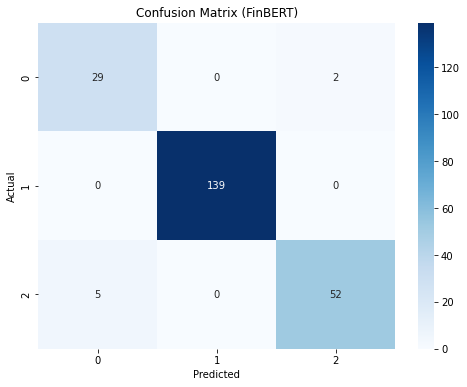

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (FinBERT)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 12. ERROR ANALYSIS

In [13]:
errors = test_df.copy()
errors["pred"] = y_pred

misclassified = errors[errors["label"] != errors["pred"]]

print("\nSample Misclassifications:")
print(misclassified[["text", "label", "pred"]].head(10))


Sample Misclassifications:
                                                   text  label  pred
345   Unit costs for flight operations fell by 6.4 p...      2     0
337   The new factory working model and reorganisati...      2     0
461   However , sales volumes in the food industry a...      2     0
371   Finnish power supply solutions and systems pro...      0     2
1862  In the third quarter of fiscal 2008 Efore swun...      0     2
800   Favourable currency rates also contributed to ...      2     0
1917  Cash flow from business operations totalled EU...      2     0


# 13. MODEL COMPARISON SUMMARY

In [14]:
baseline_acc = accuracy_score(y_test, y_pred_baseline)
finbert_acc = accuracy_score(y_true, y_pred)

print("\nModel Comparison:")
print(f"Baseline Accuracy: {baseline_acc:.4f}")
print(f"FinBERT Accuracy: {finbert_acc:.4f}")


Model Comparison:
Baseline Accuracy: 0.8502
FinBERT Accuracy: 0.9692
